In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Hotel Clustering") \
    .getOrCreate()

train_df = spark.read.parquet("data/hotel_train_vectorized.parquet")
test_df = spark.read.parquet("data/hotel_test_vectorized.parquet")

In [2]:
from pyspark.sql import DataFrame

cluster_df = train_df.union(test_df)

print("Total records:", cluster_df.count())
cluster_df.printSchema()

Total records: 118321
root
 |-- features: vector (nullable = true)
 |-- label: integer (nullable = true)



In [3]:
cluster_df = cluster_df.select("features")

cluster_df.show(5)

+--------------------+
|            features|
+--------------------+
|(534,[0,6,180,186...|
|(534,[0,6,181,187...|
|(534,[0,6,177,185...|
|(534,[0,6,177,185...|
|(534,[4,5,180,186...|
+--------------------+
only showing top 5 rows


In [4]:
from pyspark.ml.clustering import KMeans


In [5]:
#tính WCSS
wcss = []

for k in range(2, 11):

    kmeans = KMeans(
        featuresCol="features",
        predictionCol="cluster",
        k=k,
        seed=42
    )

    model = kmeans.fit(cluster_df)

    wcss.append(model.summary.trainingCost)

print(wcss)

[1455201.1582649266, 1350667.1367047424, 1231684.0902155652, 1189255.0544462686, 1119249.3729596848, 1010916.6614261738, 1015444.4048005027, 962339.0276703394, 853992.3006639292]


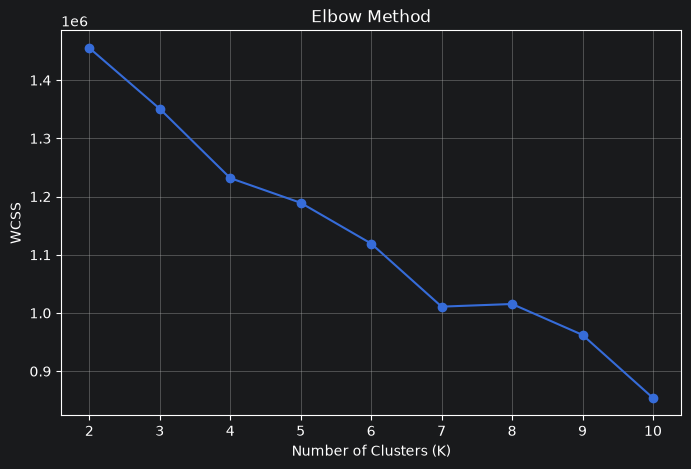

In [6]:
#vẽ elbow
import matplotlib.pyplot as plt

k_values = list(range(2, 11))

plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)

plt.show()

In [7]:
#silhouette score
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

results = []

for k in range(2, 11):

    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="features"
    )

    model = kmeans.fit(cluster_df)

    pred = model.transform(cluster_df)

    silhouette = ClusteringEvaluator(
        featuresCol="features",
        predictionCol="prediction"
    ).evaluate(pred)

    results.append((k, silhouette))

    print(f"K={k} | Silhouette={silhouette:.4f}")

K=2 | Silhouette=0.1944
K=3 | Silhouette=0.1628
K=4 | Silhouette=0.1701
K=5 | Silhouette=0.1331
K=6 | Silhouette=0.1134
K=7 | Silhouette=0.1852
K=8 | Silhouette=0.1609
K=9 | Silhouette=0.1469
K=10 | Silhouette=0.2060


In [8]:
#huấn luyện kmean với k=4
kmeans = KMeans(
    k=4,
    seed=42,
    featuresCol="features"
)

kmeans_model = kmeans.fit(cluster_df)

cluster_result = kmeans_model.transform(cluster_df)

In [9]:
#kiểm tra phân bố cụm
cluster_result.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1|47438|
|         3|15620|
|         2| 6209|
|         0|49054|
+----------+-----+



In [10]:
#tính silhouette score
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="prediction"
)

silhouette = evaluator.evaluate(cluster_result)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.1701


In [11]:
#centroid
centers = kmeans_model.clusterCenters()

print("Number of clusters:", len(centers))
print("Dimension:", len(centers[0]))

Number of clusters: 4
Dimension: 534


In [12]:
#đọc file mapping
import pandas as pd

mapping = pd.read_csv("data/feature_mapping.csv")

print(mapping.head())
print(mapping.shape)

   feature_index        feature_name
0              0         meal_vec_BB
1              1         meal_vec_HB
2              2         meal_vec_SC
3              3  meal_vec_Undefined
4              4         meal_vec_FB
(534, 2)


In [13]:
print(len(centers[0]))
print(mapping.shape)

534
(534, 2)


In [14]:
mapping.shape
mapping.head()

,feature_index,feature_name
0,0,meal_vec_BB
1,1,meal_vec_HB
2,2,meal_vec_SC
3,3,meal_vec_Undefined
4,4,meal_vec_FB


In [15]:
#top feature của từng cluster
import pandas as pd
import numpy as np

feature_names = mapping["feature_name"].tolist()

for cluster_id, center in enumerate(centers):

    cluster_df = pd.DataFrame({
        "feature": feature_names,
        "centroid_value": center
    })

    cluster_df["abs_value"] = np.abs(cluster_df["centroid_value"])

    top_features = cluster_df.sort_values(
        by="abs_value",
        ascending=False
    ).head(10)

    print("=" * 60)
    print(f"CLUSTER {cluster_id}")
    print("=" * 60)

    print(
        top_features[
            ["feature", "centroid_value"]
        ].to_string(index=False)
    )

    print("\n")

CLUSTER 0
                       feature  centroid_value
      reserved_room_type_vec_A        0.893024
                   meal_vec_BB        0.817227
   deposit_type_vec_No Deposit        0.777320
distribution_channel_vec_TA/TO        0.714064
          hotel_vec_City Hotel        0.695508
   customer_type_vec_Transient        0.602398
               country_vec_PRT        0.586615
     total_of_special_requests       -0.571964
                  total_guests       -0.479524
          total_estimated_cost       -0.431980


CLUSTER 1
                       feature  centroid_value
   deposit_type_vec_No Deposit        0.999579
distribution_channel_vec_TA/TO        0.923648
   customer_type_vec_Transient        0.911467
  market_segment_vec_Online TA        0.879391
                   meal_vec_BB        0.759310
          hotel_vec_City Hotel        0.748793
      reserved_room_type_vec_A        0.624012
     total_of_special_requests        0.592621
                   agent_vec_9        

In [16]:
cluster_id = 1
cluster_id = 2
cluster_id = 3

In [17]:
#PCA xuống 2 chiều
from pyspark.ml.feature import PCA

pca = PCA(
    k=2,
    inputCol="features",
    outputCol="pca_features"
)

pca_model = pca.fit(cluster_result)

pca_df = pca_model.transform(cluster_result)

pca_df.select(
    "prediction",
    "pca_features"
).show(5, truncate=False)

+----------+-----------------------------------------+
|prediction|pca_features                             |
+----------+-----------------------------------------+
|0         |[-1.5761946366845287,1.2937500832033269] |
|0         |[-1.6051051331866113,1.172374596283429]  |
|1         |[0.01746179485964794,1.331067053813861]  |
|1         |[0.01746179485964794,1.331067053813861]  |
|1         |[-0.15896711247988002,1.2668179815216187]|
+----------+-----------------------------------------+
only showing top 5 rows


In [18]:
import pandas as pd

pca_pd = pca_df.select(
    "prediction",
    "pca_features"
).toPandas()
pca_pd["PC1"] = pca_pd["pca_features"].apply(lambda x: float(x[0]))
pca_pd["PC2"] = pca_pd["pca_features"].apply(lambda x: float(x[1]))

pca_pd.head()

,prediction,pca_features,PC1,PC2
0,0,"[-1.5761946366845287, 1.2937500832033269]",-1.576195,1.293750
1,0,"[-1.6051051331866113, 1.172374596283429]",-1.605105,1.172375
2,1,"[0.01746179485964794, 1.331067053813861]",0.017462,1.331067
3,1,"[0.01746179485964794, 1.331067053813861]",0.017462,1.331067
4,1,"[-0.15896711247988002, 1.2668179815216187]",-0.158967,1.266818


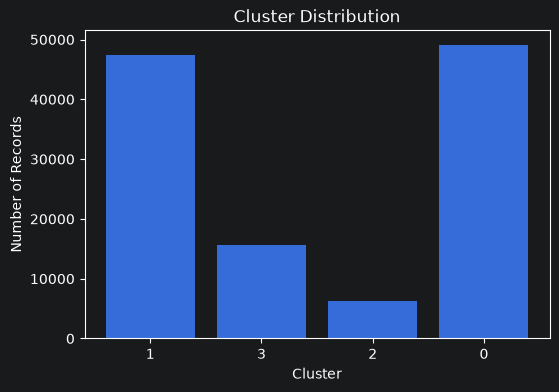

In [19]:
#bar chart
cluster_counts = (
    cluster_result.groupBy("prediction")
    .count()
    .toPandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    cluster_counts["prediction"].astype(str),
    cluster_counts["count"]
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.show()

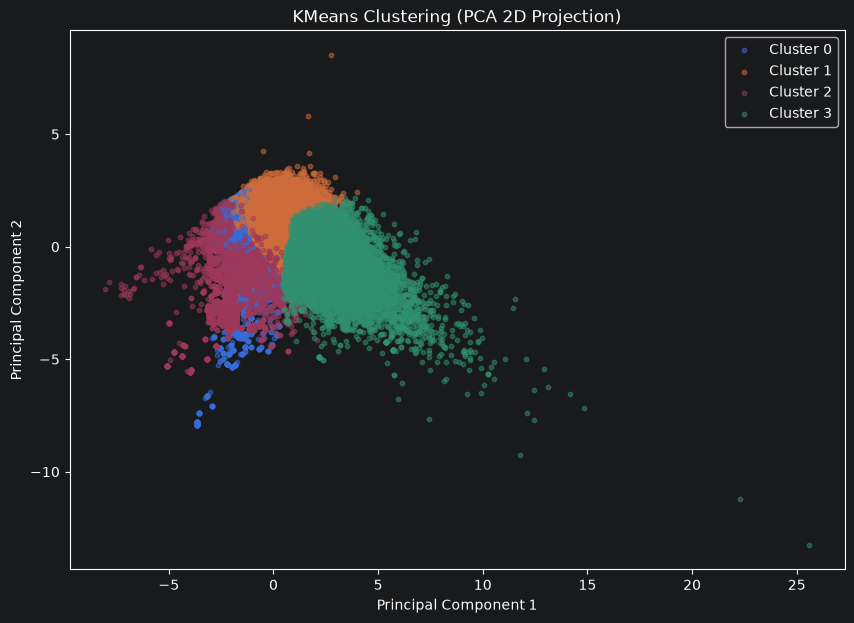

In [20]:
#vẽ scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_pd["prediction"].unique()):

    subset = pca_pd[pca_pd["prediction"] == cluster]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.5,
        s=10
    )

plt.title("KMeans Clustering (PCA 2D Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()